In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

from src.features.hog import extract_hog_dataset


In [3]:
from pathlib import Path

DATA_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = Path("results/feature_extraction")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

images = []
labels = []

for label, cls in enumerate(["normal", "tuberculosis"]):
    class_dir = DATA_DIR / cls

    for img_path in class_dir.iterdir():
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        images.append(img)
        labels.append(label)

images = np.array(images)
labels = np.array(labels)

print(images.shape, labels.shape)


(30, 244, 244) (30,)


In [4]:
hog_features = extract_hog_dataset(images)
hog_features.shape


(30, 7056)

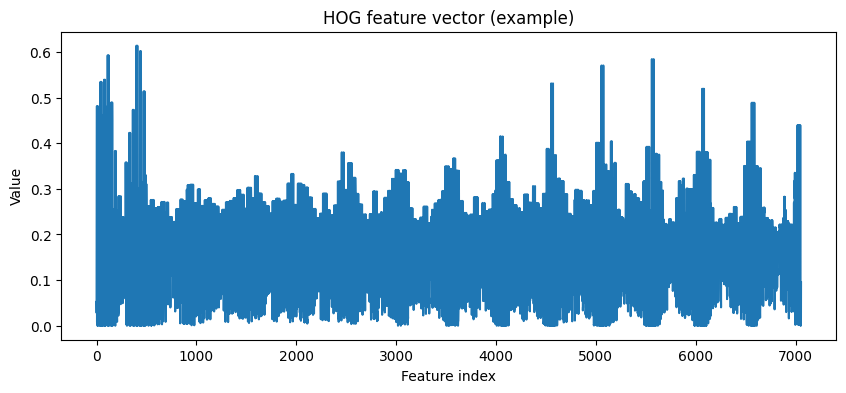

In [5]:
plt.figure(figsize=(10, 4))
plt.plot(hog_features[0])
plt.title("HOG feature vector (example)")
plt.xlabel("Feature index")
plt.ylabel("Value")
plt.savefig(
    RESULTS_DIR / "hog_feature_vector_example.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()